# Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the cleaned dataset, understand customer behavior, identify patterns related to customer churn, and extract business insights that can support strategic decision-making.

# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

# Load the Cleaned Dataset

In [2]:
df = pd.read_csv("../data/processed_data.csv")

# Dataset Overview

In [3]:
df.head()

,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [4]:
df.shape

(7032, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              7032 non-null   object 
 1   City               7032 non-null   object 
 2   Zip Code           7032 non-null   int64  
 3   Lat Long           7032 non-null   object 
 4   Latitude           7032 non-null   float64
 5   Longitude          7032 non-null   float64
 6   Gender             7032 non-null   object 
 7   Senior Citizen     7032 non-null   object 
 8   Partner            7032 non-null   object 
 9   Dependents         7032 non-null   object 
 10  Tenure Months      7032 non-null   int64  
 11  Phone Service      7032 non-null   object 
 12  Multiple Lines     7032 non-null   object 
 13  Internet Service   7032 non-null   object 
 14  Online Security    7032 non-null   object 
 15  Online Backup      7032 non-null   object 
 16  Device Protection  7032 

# Overall Churn Rate

In [6]:
churn = (
    df["Churn Value"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn

Churn Value
0    73.42
1    26.58
Name: proportion, dtype: float64

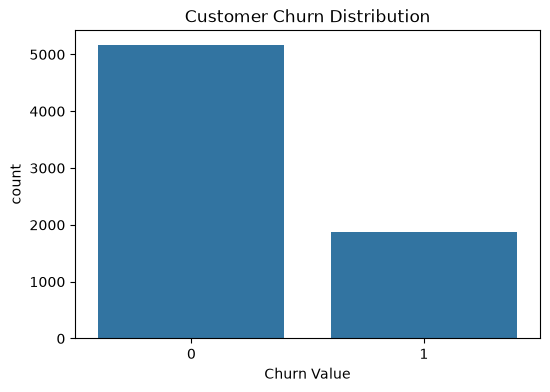

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn Value"
)

plt.title("Customer Churn Distribution")

plt.show()

### Business Insight

The overall churn rate is **26.5%**, meaning roughly 1 in 4 customers has left the company.

This serves as the baseline for evaluating retention strategies and future predictive models.

# Customer Demographics

## Churn by Gender

In [8]:
pd.crosstab(
    df["Gender"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Gender,,
Female,0.730,0.270
Male,0.738,0.262


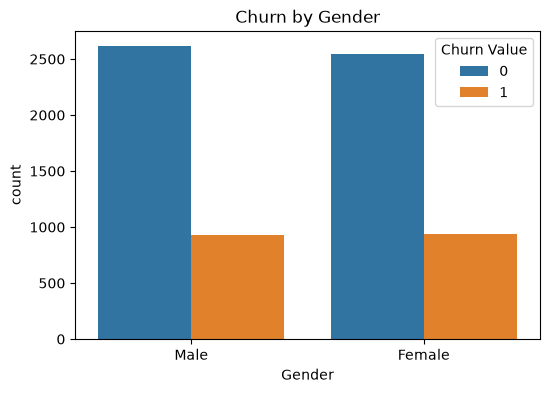

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Value"
)

plt.title("Churn by Gender")

plt.show()

### Business Insight

Customer churn rates are very similar across both genders. Female customers have a churn rate of **27.0%**, while male customers have a churn rate of **26.2%**.

This small difference suggests that **gender is not a strong predictor of customer churn**. Therefore, customer retention strategies should focus on other factors such as contract type, tenure, pricing, and subscribed services rather than gender.

## Churn by Senior Citizen

In [10]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Senior Citizen,,
No,0.763,0.237
Yes,0.583,0.417


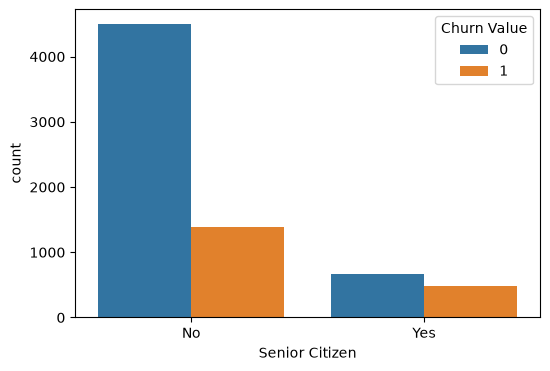

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Value"
)

plt.show()

### Business Insight

Senior citizens have a significantly higher churn rate than non-senior customers. While **23.7%** of non-senior customers churned, the churn rate increased to **41.7%** among senior citizens.

This finding suggests that senior customers are more likely to leave the company. The business should investigate the reasons behind this behavior and consider targeted retention strategies, such as simplified service plans, dedicated customer support, or loyalty programs designed specifically for senior customers.

## Churn by Partner Status

In [12]:
pd.crosstab(
    df["Partner"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Partner,,
No,0.670,0.330
Yes,0.803,0.197


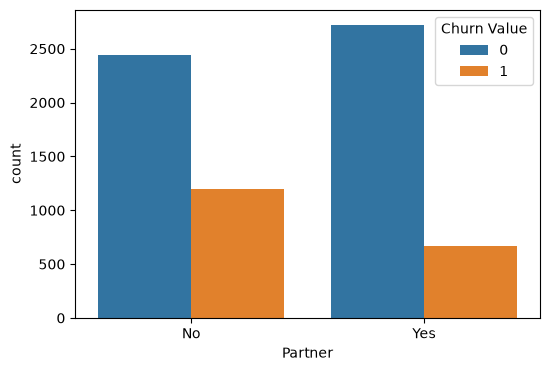

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn Value"
)

plt.show()

### Business Insight

Customers with a partner have a considerably lower churn rate than those without a partner. The churn rate is **19.7%** for customers with a partner, compared to **33.0%** for customers without one.

This suggests that customers with partners tend to have stronger long-term relationships with the company. Customers without partners represent a higher-risk segment and may benefit from personalized retention campaigns and loyalty incentives.

## Churn by Dependents

In [14]:
pd.crosstab(
    df["Dependents"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Dependents,,
No,0.674,0.326
Yes,0.935,0.065


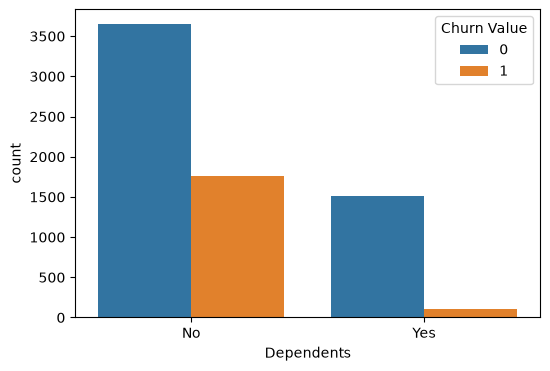

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn Value"
)

plt.show()

### Business Insight

Customers with dependents have a substantially lower churn rate than customers without dependents. Only **6.5%** of customers with dependents churned, compared to **32.6%** of customers without dependents.

This indicates that customers with dependents are significantly more loyal and are less likely to leave the company. In contrast, customers without dependents should be considered a higher-priority group for retention efforts, as they exhibit a much higher likelihood of churn.

# Customer Relationship Analysis

## Tenure Distribution

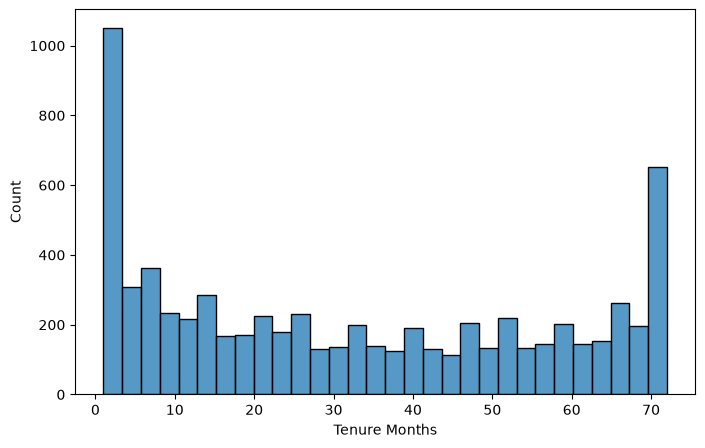

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    bins=30
)

plt.show()

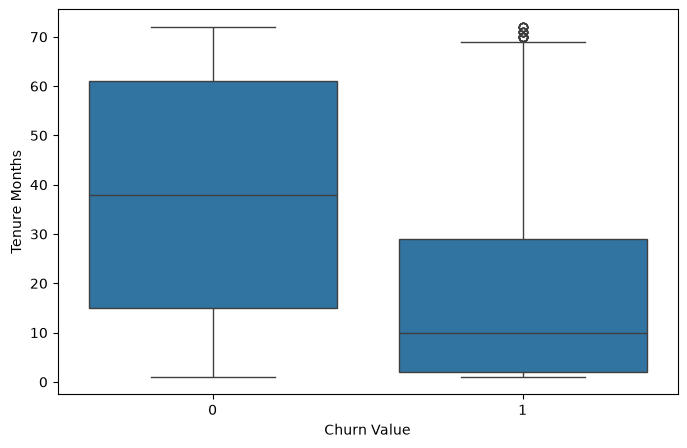

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Tenure Months"
)

plt.show()

### Business Insight

Customer tenure is a strong predictor of churn. Customers who churned had a median tenure of only **10 months**, compared to **38 months** for customers who stayed.

This indicates that churn risk is highest during the early stages of the customer lifecycle. Retention efforts should be prioritized for customers within their first 12 months, as long-tenured customers show much stronger loyalty and lower churn risk.

# Service Analysis

## Churn by Internet Service

In [18]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Internet Service,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


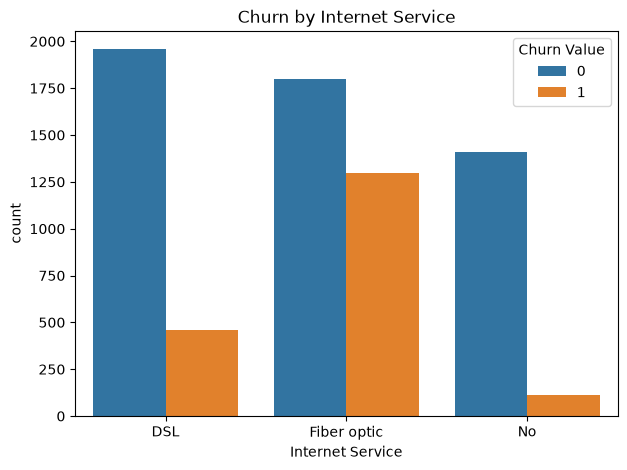

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Value"
)

plt.title("Churn by Internet Service")

plt.show()

### Business Insight

Internet service type has a major impact on churn. **Fiber optic** customers churn at **42%**, compared to only **19%** for DSL and **7%** for customers with no internet service.

This suggests dissatisfaction with the fiber optic service (likely pricing or reliability) rather than internet usage itself is driving churn. Fiber optic customers should be a top priority for retention efforts.

## Churn by Online Security

In [20]:
pd.crosstab(
    df["Online Security"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Online Security,,
No,0.582,0.418
No internet service,0.926,0.074
Yes,0.854,0.146


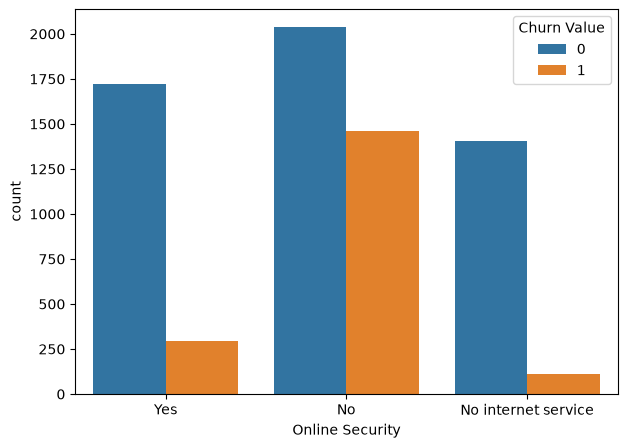

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Online Security",
    hue="Churn Value"
)

plt.show()

### Business Insight

Customers without Online Security have a much higher churn rate (**42%**) compared to those who have it (**15%**).

This indicates that offering or upselling Online Security to at-risk customers could be an effective, low-cost lever to reduce churn.

## Churn by Online Backup

In [22]:
pd.crosstab(
    df["Online Backup"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Online Backup,,
No,0.601,0.399
No internet service,0.926,0.074
Yes,0.784,0.216


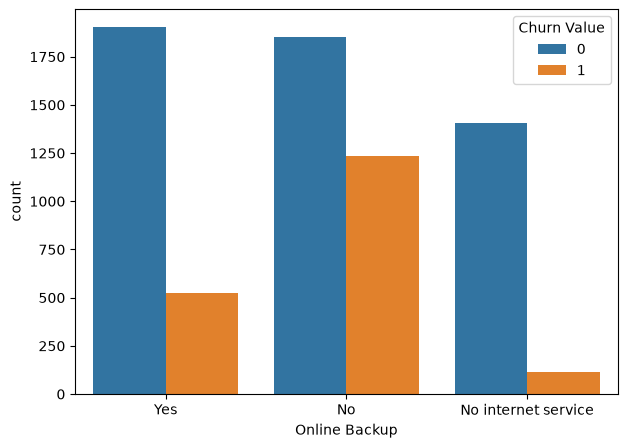

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Online Backup",
    hue="Churn Value"
)

plt.show()

### Business Insight

Customers without Online Backup churn at **40%**, more than double the rate of customers who have it (**21%**).

Bundling or promoting Online Backup may help increase customer stickiness and reduce churn.


## Churn by Device Protection

In [24]:
pd.crosstab(
    df["Device Protection"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Device Protection,,
No,0.609,0.391
No internet service,0.926,0.074
Yes,0.775,0.225


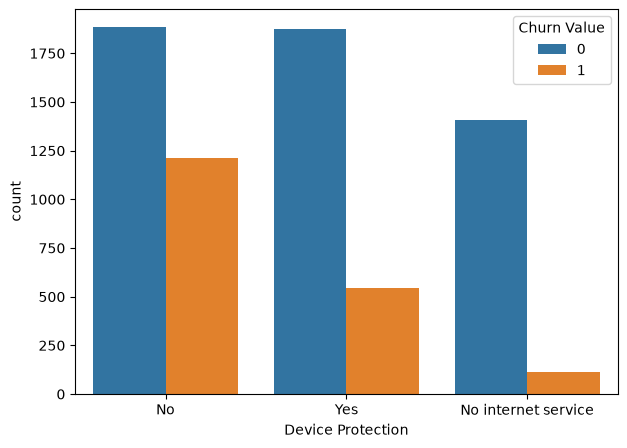

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Device Protection",
    hue="Churn Value"
)

plt.show()

### Business Insight

Customers without Device Protection churn at **39%**, compared to **22%** for those who have it.

Similar to other add-on services, lack of Device Protection is associated with higher churn risk, suggesting value-added services increase retention.

## Churn by Tech Support

In [26]:
pd.crosstab(
    df["Tech Support"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Tech Support,,
No,0.584,0.416
No internet service,0.926,0.074
Yes,0.848,0.152


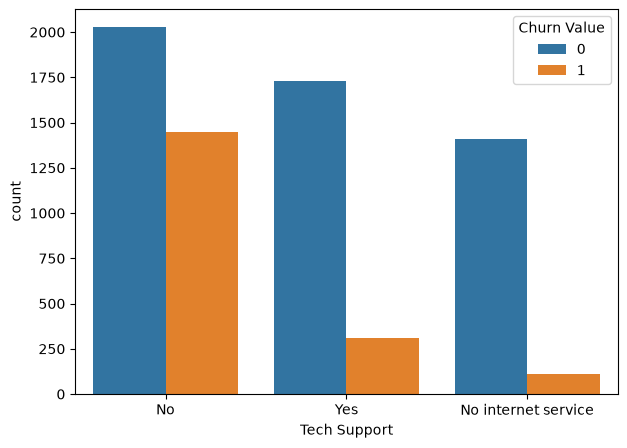

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Value"
)

plt.show()

### Business Insight

Tech Support shows one of the strongest effects on churn: customers without it churn at **42%**, versus just **15%** for those who have it.

This is the largest gap among the add-on services, making Tech Support a strong candidate for proactive retention offers.

## Churn by Streaming TV

In [28]:
pd.crosstab(
    df["Streaming TV"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Streaming TV,,
No,0.665,0.335
No internet service,0.926,0.074
Yes,0.699,0.301


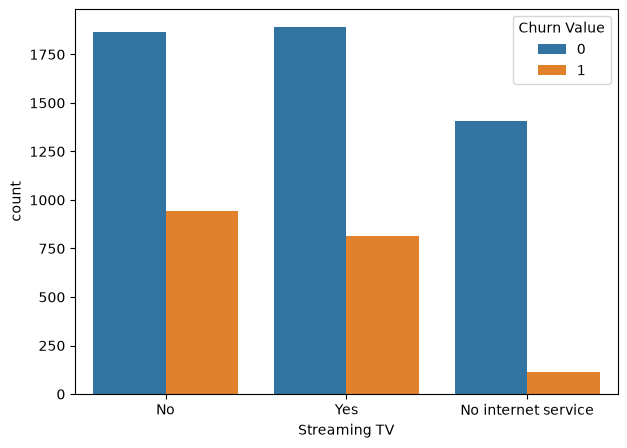

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Streaming TV",
    hue="Churn Value"
)

plt.show()

### Business Insight

Streaming TV shows only a small difference in churn between users (**30%**) and non-users (**34%**).

Unlike security or support services, streaming add-ons appear to have a weak relationship with churn and are a lower priority for retention strategy.

## Churn by Streaming Movies

In [30]:
pd.crosstab(
    df["Streaming Movies"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Streaming Movies,,
No,0.663,0.337
No internet service,0.926,0.074
Yes,0.700,0.300


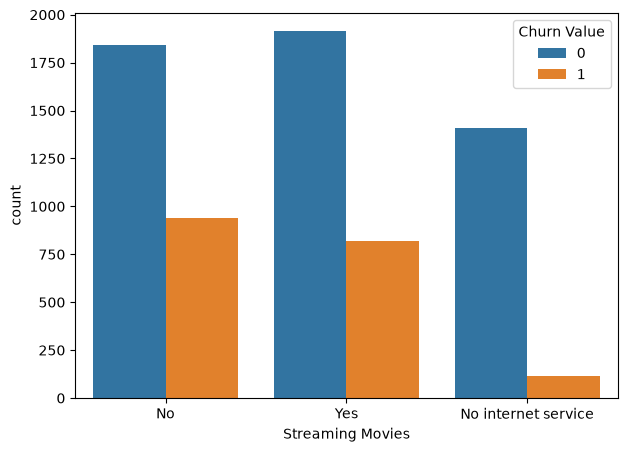

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Streaming Movies",
    hue="Churn Value"
)

plt.show()

### Business Insight

Streaming Movies shows a similarly weak effect on churn, with non-users at **34%** and users at **30%**.

This confirms that entertainment add-ons (Streaming TV/Movies) are less predictive of churn compared to support-related services like Tech Support and Online Security.

## Churn by Contract Type

In [32]:
pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


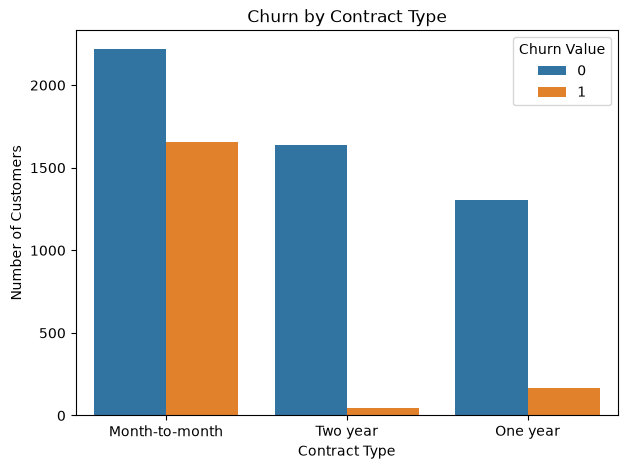

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Value"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

Contract type is one of the strongest churn drivers. **Month-to-month** customers churn at roughly **43%**, compared to just **11%** for One-year and **3%** for Two-year contracts.

This shows that longer-term contracts strongly lock in retention. Converting month-to-month customers to annual contracts (via discounts or incentives) could significantly reduce overall churn.

## Churn by Payment Method

In [34]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Payment Method,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.847,0.153
Electronic check,0.547,0.453
Mailed check,0.808,0.192


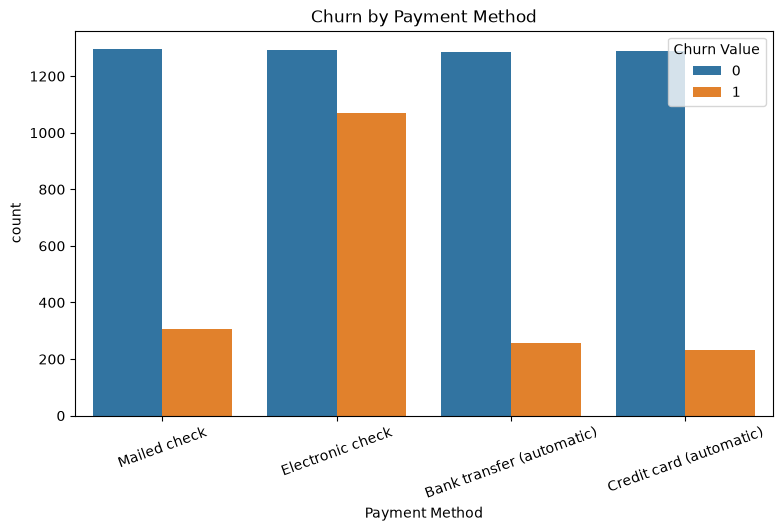

In [35]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Value"
)

plt.xticks(rotation=20)
plt.title("Churn by Payment Method")

plt.show()

### Business Insight

Payment method has a clear impact on churn. Customers paying via **Electronic check** churn at roughly **45%**, far higher than Mailed check (**19%**), Bank transfer (**17%**), or Credit card (**15%**).

This suggests electronic check users may be less engaged or more price-sensitive. Encouraging migration to automatic payment methods (bank transfer or credit card) could help reduce churn.

## Churn by Paperless Billing

In [36]:
pd.crosstab(
    df["Paperless Billing"],
    df["Churn Value"],
    normalize="index"
).round(3)

Churn Value,0,1
Paperless Billing,,
No,0.836,0.164
Yes,0.664,0.336


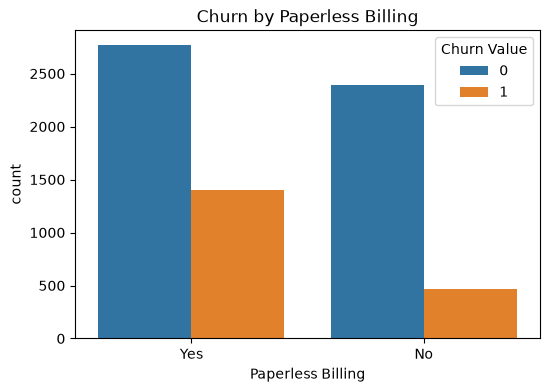

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Paperless Billing",
    hue="Churn Value"
)

plt.title("Churn by Paperless Billing")

plt.show()

### Business Insight

Customers with Paperless Billing churn at **34%**, notably higher than the **16%** churn rate for customers without it.

While paperless billing itself isn't likely the cause, it may correlate with more price-sensitive or less loyal customer segments, making it a useful flag for targeted retention efforts.

## Monthly Charges Distribution

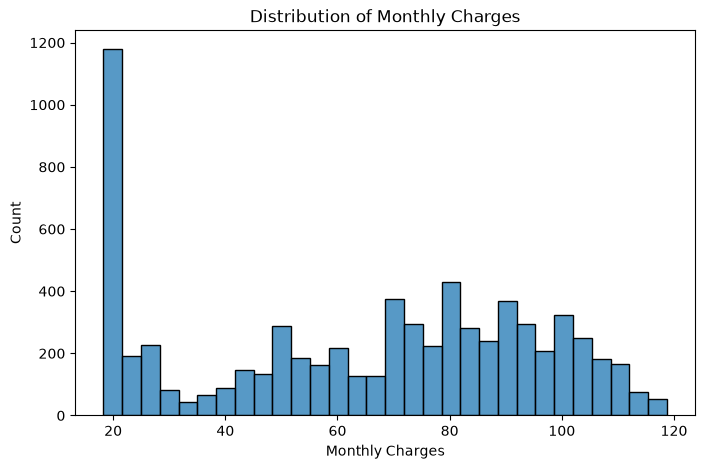

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    bins=30
)

plt.title("Distribution of Monthly Charges")

plt.show()

### Business Insight

Monthly charges show a large concentration of customers around **$20**, with a second broad cluster between **$70-100**.

This suggests two distinct customer segments: low-cost, likely single-service subscribers, and higher-spending, likely bundled-service subscribers. Pricing and retention strategies should be tailored separately for these two groups.

## Monthly Charges by Churn Status

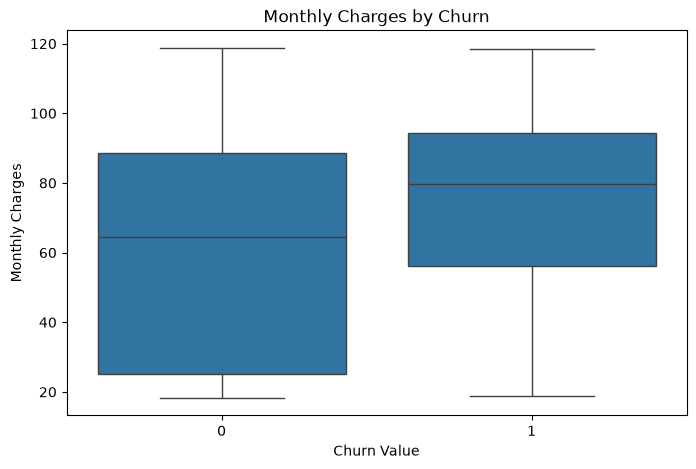

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")

plt.show()

### Business Insight

Churned customers have higher monthly charges, with a median of **$80** compared to **$65** for retained customers.

This suggests price sensitivity is a factor in churn — customers on higher-cost plans may need stronger value communication or loyalty incentives to justify their spending.

## Total Charges Distribution

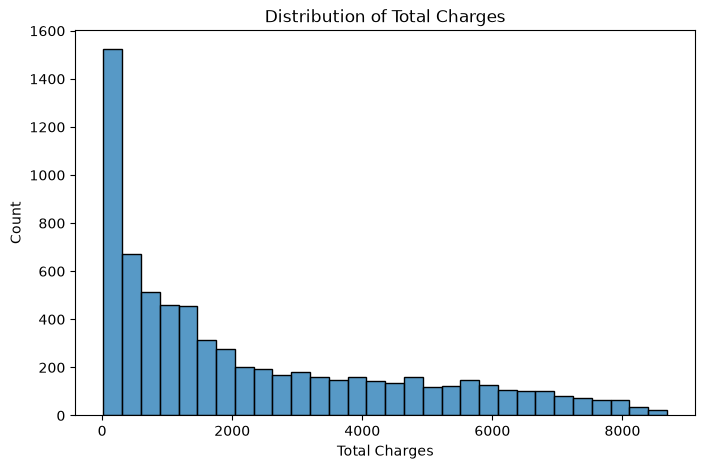

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total Charges",
    bins=30
)

plt.title("Distribution of Total Charges")

plt.show()

### Business Insight

Total Charges is heavily right-skewed, with a large concentration of customers under **$500**, reflecting the high volume of short-tenure customers.

This distribution mirrors the tenure pattern, reinforcing that a significant portion of the customer base is still early in their lifecycle and hasn't accumulated high lifetime value yet.

## Total Charges by Churn Status

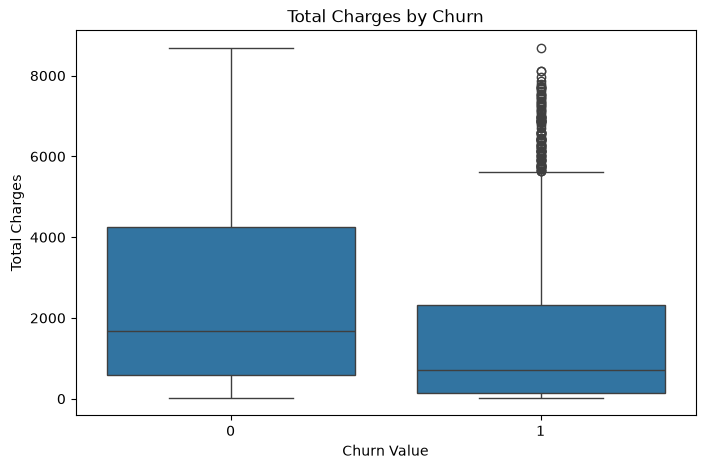

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Total Charges"
)

plt.title("Total Charges by Churn")

plt.show()

### Business Insight

Churned customers have a much lower median Total Charges (**~$700**) compared to retained customers (**~$1,700**).

This is consistent with churn happening early in the customer lifecycle — customers leave before accumulating significant lifetime value, reinforcing the priority of early-tenure retention efforts.

# Geographic Analysis

## Churn by State

In [46]:
state_churn = (
    pd.crosstab(
        df["State"],
        df["Churn Value"],
        normalize="index"
    )[1]
    .sort_values(ascending=False)
)

state_churn.head(10)

State
California    0.265785
Name: 1, dtype: float64

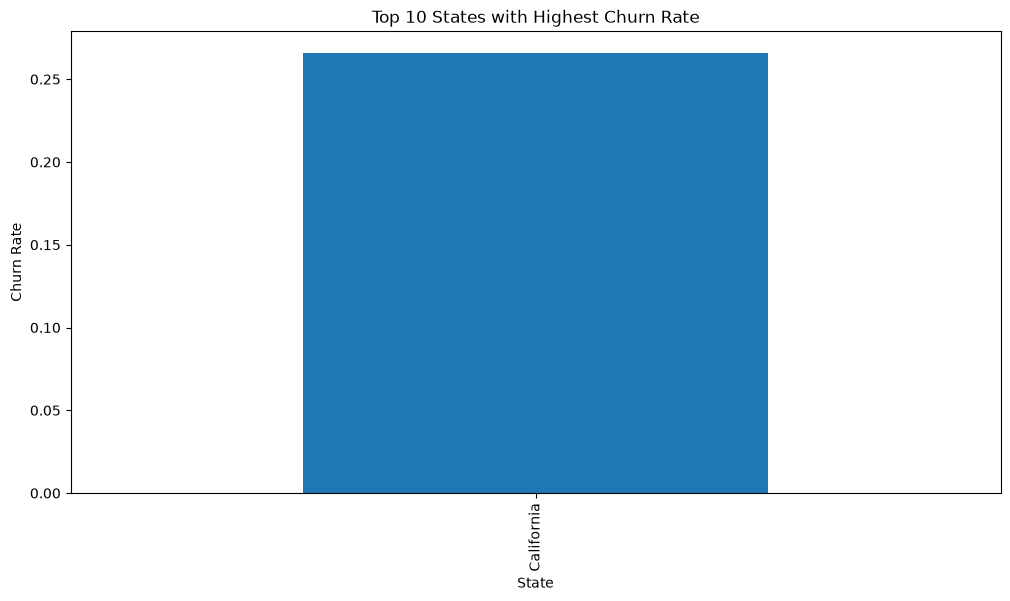

In [47]:
plt.figure(figsize=(12,6))

state_churn.head(10).plot(kind="bar")

plt.title("Top 10 States with Highest Churn Rate")
plt.ylabel("Churn Rate")

plt.show()

### Business Insight

All customers in the dataset are located in **California**, with an overall churn rate of **~26.5%**.

Since there's no state-level variation, geography isn't a useful segmentation variable here — retention strategies should instead focus on the stronger drivers already identified (contract type, tenure, internet service, and support add-ons).

## Churn by City

In [49]:
city_churn = (
    pd.crosstab(
        df["City"],
        df["Churn Value"],
        normalize="index"
    )[1]
    .sort_values(ascending=False)
)

city_churn.head(10)

City
Wrightwood       1.0
Tipton           1.0
Truckee          1.0
Twain            1.0
Johannesburg     1.0
Fort Jones       1.0
Smith River      1.0
Maricopa         1.0
Boulder Creek    1.0
Riverbank        1.0
Name: 1, dtype: float64

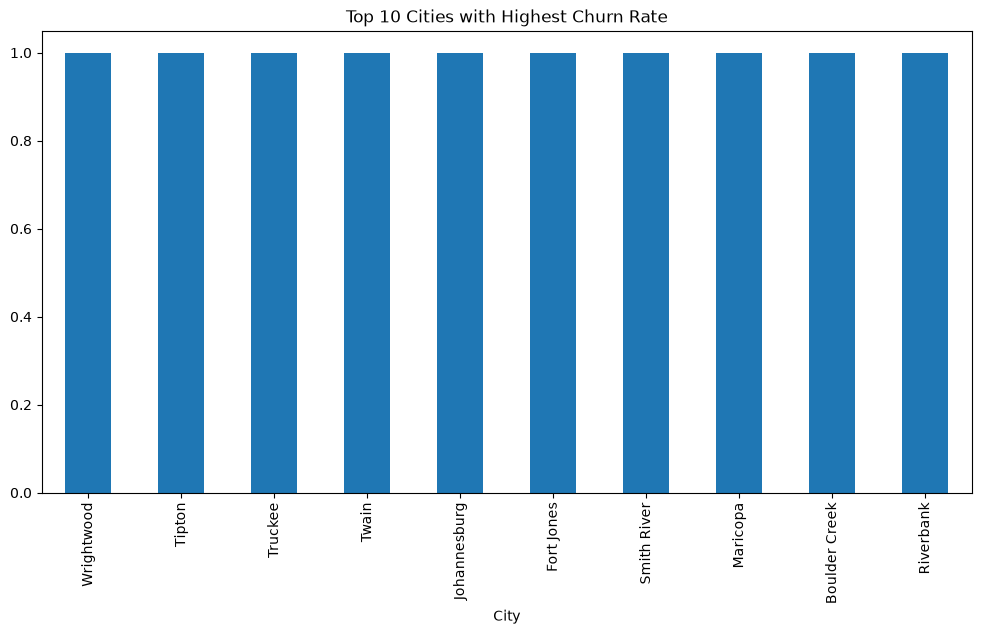

In [50]:
plt.figure(figsize=(12,6))

city_churn.head(10).plot(kind="bar")

plt.title("Top 10 Cities with Highest Churn Rate")

plt.show()

### Business Insight

The top 10 cities shown have a **100% churn rate**, but this is likely due to very small customer counts per city (e.g., 1 customer = 100% churn) rather than a real geographic trend.

These results should not be treated as reliable business insight — city-level churn rate needs to be filtered by a minimum customer count before drawing conclusions.

# Correlation Analysis

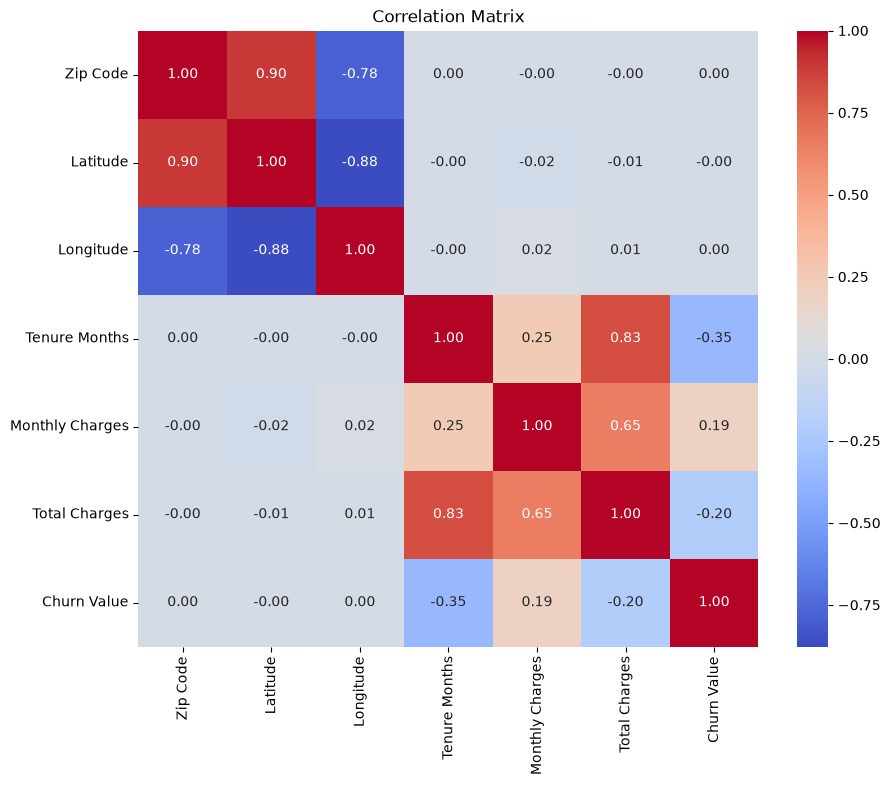

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Business Insight

Tenure Months has the strongest correlation with Churn (**-0.35**), followed by Total Charges (**-0.20**) and Monthly Charges (**+0.19**).

This confirms tenure as the most influential numeric driver of churn, while higher monthly charges slightly increase churn risk — reinforcing that new, high-paying customers are the highest-risk segment.

# Executive Summary
## Key Business Findings

- Customer churn is strongly associated with contract type, tenure, and monthly charges.
- Senior citizens exhibit a noticeably higher churn rate than younger customers.
- Customers without partners or dependents are more likely to leave the company.
- Value-added services such as online security and technical support are associated with improved customer retention.
- Geographic analysis showed no meaningful variation, as the dataset is limited to California with insufficient city-level sample sizes.
- Customers with short tenure and month-to-month contracts represent the highest-risk segment.

# Business Recommendations
## Recommendations

- Prioritize retention campaigns for customers with month-to-month contracts.
- Encourage customers to switch to long-term contracts through discounts and loyalty incentives.
- Improve customer onboarding during the first months of the subscription lifecycle.
- Promote value-added services such as technical support and online security.
- Develop personalized retention strategies for senior customers and other high-risk customer segments.
- Offer incentives to shift customers from Electronic Check to automatic payment methods to reduce churn.